<a href="https://colab.research.google.com/github/martinruhle/curso-ciencia-datos-2027-1/blob/lab03/eda_cohorte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 03 — EDA sobre una cohorte de diabetes tipo 2

**Sesión 03:** Python para Biomedicina: Visualización y Análisis Exploratorio

Continúa el dataset de Synthea del lab02 (23 018 pacientes, 17 355 578 observaciones).
Se define una cohorte clínica, se ejecuta el checklist de EDA de la sesión y se producen
figuras publicables.

> **Regla de trabajo, heredada del lab02.** Los filtros clínicos se hacen **por código**
> (SNOMED / LOINC), nunca por subcadena de la descripción. La búsqueda por texto se usa
> únicamente para *descubrir* qué códigos existen; la definición de cohorte y de analito
> se ancla en el código. Es el mismo principio que sostiene el uso de vocabularios
> estándar en OMOP y el que evitó, en el lab02, mezclar el IMC en razón con el percentil
> pediátrico.


## 0. Entorno

### 0.1 Dependencias

`tableone` genera la tabla de características basales; `lifelines` es opcional (curva
de Kaplan–Meier de la sección extra). El resto viene preinstalado en Colab.


In [1]:
!pip install -q tableone lifelines


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 3.6 MB/s eta 0:00:00


### 0.2 Módulo de funciones puras

Las funciones sin estado (normalización de fechas, edad en la fecha índice, ventana
basal, atrición) viven en `eda_utils.py`, no en el notebook. Motivo: el criterio de
evaluación pide que `ruff check` y `pytest` pasen, y un `.ipynb` no es testeable.
Subí `eda_utils.py` y `test_eda_utils.py` al mismo directorio que este notebook (ajustando `sys.path`).


In [2]:
import sys
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

# Los .py están en Drive junto al notebook, se agrega su carpeta al path:
sys.path.insert(0, '/content/drive/MyDrive/curso-cd-2027/lab03')

from eda_utils import (
    a_dia_naive,
    a_dia_naive_escalar,
    edad_en_fecha,
    marcar_implausibles,
    tabla_atricion,
    valor_basal,
)
print('eda_utils importado OK')


Mounted at /content/drive
eda_utils importado OK


In [3]:
# Verificación de la calidad del código (criterio de evaluación del lab)
!pip install -q ruff pytest

# Se mueve el cwd del notebook
%cd /content/drive/MyDrive/curso-cd-2027/lab03
!ruff check eda_utils.py test_eda_utils.py
!python -m pytest test_eda_utils.py -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 57.2 MB/s eta 0:00:00
/content/drive/MyDrive/curso-cd-2027/lab03
All checks passed!
..........                                                               [100%]
10 passed in 1.45s


### 0.3 Rutas y carga del estado del lab02

El lab02 dejó tres DataFrames ya tipados en `ckpt/` (Parquet, que conserva el esquema:
`category`, `float32` y `datetime64[ns, UTC]` vuelven intactos). Este laboratorio los
**consume sin modificarlos** y agrega una tabla que el lab02 nunca cargó:
`conditions.csv`.


In [126]:
import gc

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE02 = Path('/content/drive/MyDrive/curso-cd-2027/lab02')
BASE03 = Path('/content/drive/MyDrive/curso-cd-2027/lab03')
DATA   = BASE02 / 'data'      # CSV originales de Synthea
CKPT   = BASE02 / 'ckpt'      # checkpoints tipados del lab02
FIG    = BASE03 / 'figuras'   # entregable del lab03
FIG.mkdir(parents=True, exist_ok=True)

assert (CKPT / 'obs.parquet').exists(), 'Falta el checkpoint del lab02'
assert (DATA / 'conditions.csv').exists(), 'Falta conditions.csv en DATA'
print('rutas OK')


rutas OK


In [127]:
obs = pd.read_parquet(CKPT / 'obs.parquet')
p8  = pd.read_parquet(CKPT / 'p8.parquet')
enc = pd.read_parquet(CKPT / 'enc_tip.parquet')

print('observations:', obs.shape)
print('patients    :', p8.shape)
print('encounters  :', enc.shape)
print()
print(obs.dtypes)


observations: (17355578, 10)
patients    : (23018, 8)
encounters  : (1355775, 7)

DATE           datetime64[ns, UTC]
PATIENT                   category
ENCOUNTER                 category
CATEGORY                  category
CODE                      category
DESCRIPTION               category
UNITS                     category
TYPE                      category
VALUE_num                  float32
VALUE_cat                 category
dtype: object


### 0.4 `conditions.csv` — la tabla nueva, y su trampa de tipos

Los códigos de `conditions` son **SNOMED CT**, y a diferencia de LOINC son cadenas de
dígitos sin separadores. Si se deja inferir el tipo, pandas los lee como `int64`: se
pierden los ceros a la izquierda si los hubiera y, sobre todo, se convierte un
identificador en un número sobre el que tiene sentido calcular medias. Se fuerza `str`
en la lectura y se convierte a `category` después.

También se lee la lista de columnas primero: distintas versiones de Synthea exportan
una columna `SYSTEM` adicional, y un `usecols` fijo rompería con las versiones que no
la tienen.


In [128]:
cols_disponibles = pd.read_csv(DATA / 'conditions.csv', nrows=0).columns.tolist()
print('columnas en conditions.csv:', cols_disponibles)

deseadas = ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']
usar = [c for c in deseadas if c in cols_disponibles]

cond = pd.read_csv(
    DATA / 'conditions.csv',
    usecols=usar,
    dtype={'CODE': str, 'DESCRIPTION': 'category'},   # CODE es identificador, no número
    parse_dates=['START', 'STOP'],
)
cond['CODE'] = cond['CODE'].astype('category')
cond['PATIENT'] = cond['PATIENT'].astype(str)
cond['START'] = a_dia_naive(cond['START'])
cond['STOP'] = a_dia_naive(cond['STOP'])

print('\nconditions:', cond.shape)
print('pacientes con al menos una condición:', cond['PATIENT'].nunique())
cond.head()


columnas en conditions.csv: ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE', 'DESCRIPTION']

conditions: (835138, 6)
pacientes con al menos una condición: 23018


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2018-08-17,2018-08-17,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-4314-63c7f408666f,314529007,Medication review due (situation)
1,2018-09-21,2019-04-26,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-9997-d877d0d3c58e,314529007,Medication review due (situation)
2,2019-07-26,2019-10-25,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-89e6-a4b5a85b7e57,314529007,Medication review due (situation)
3,2019-10-01,2019-11-24,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-3dc2-b108b2dc542e,90460009,Injury of neck (disorder)
4,2019-10-01,2019-11-24,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-3dc2-b108b2dc542e,39848009,Whiplash injury to neck (disorder)


### 0.5 Estilo de figura

Se fija una única vez el estilo para todo el notebook, de modo que ninguna figura
dependa de ajustes ad hoc. Cuatro decisiones que importan para los criterios de
evaluación:

- **`pdf.fonttype = 42`** — matplotlib exporta a PDF con fuentes Type 3 por defecto, que
  muchas revistas rechazan y que Illustrator no puede editar. El 42 fuerza TrueType.
- **Paleta cualitativa `colorblind` de seaborn** y secuencial **`viridis`**: ambas son
  perceptualmente uniformes y sobreviven al daltonismo y a la impresión en gris. El
  criterio del lab lo exige explícitamente.
- **`constrained_layout`** en lugar de `tight_layout`: resuelve el solapamiento de
  etiquetas de forma determinista en figuras multipanel.
- **Tamaño en pulgadas y tipografía de 8–10 pt**: una figura de una columna de revista
  mide ~3.5 in de ancho, una de dos columnas ~7.2 in. Diseñar a ese tamaño evita el
  error clásico de una figura enorme reducida al 30 %, donde la tipografía queda
  ilegible.

> **Nota sobre la fuente.** Colab no trae Arial ni Helvetica; se usa DejaVu Sans, que es
> la de matplotlib. Si la revista exige Arial, hay que instalarla y limpiar la caché de
> fuentes.


In [129]:
sns.set_theme(context='paper', style='ticks')

PALETA = sns.color_palette('colorblind')
COLOR_SEXO = {'M': PALETA[0], 'F': PALETA[1]}
CMAP = 'viridis'          # secuencial, perceptualmente uniforme

ANCHO_1COL = 3.5          # pulgadas — una columna de revista
ANCHO_2COL = 7.2          # dos columnas

plt.rcParams.update({
    'figure.dpi': 110,            # en pantalla
    'savefig.dpi': 300,           # en disco
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,           # TrueType, no Type 3
    'ps.fonttype': 42,
    'font.size': 9,
    'axes.titlesize': 9.5,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'figure.constrained_layout.use': True,
})
print('estilo fijado')


estilo fijado


---
## Actividad 1 — Definición de la cohorte

Una cohorte no es un filtro: es una **definición** con cuatro componentes que hay que
declarar antes de escribir código. Es la estructura que se formaliza en ATLAS/OHDSI y
que se retomará en la sesión 17.

1. **Evento de entrada** — qué hecho clínico hace que un paciente entre.
2. **Fecha índice** — el instante desde el que se cuenta todo lo demás.
3. **Criterios de inclusión/exclusión** — evaluados *en relación con* la fecha índice.
4. **Fin de seguimiento** — hasta cuándo se observa a cada paciente.

Sin fecha índice no hay cohorte: hay una lista de pacientes. Toda la Actividad 3
(evolución temporal) y toda la Tabla 1 (características *basales*) dependen de ella.


### 1.1 Descubrimiento: qué códigos existen

Este paso es **exploratorio**, y por eso sí usa búsqueda por texto. La búsqueda por
subcadena sirve para saber qué hay; no sirve para definir la cohorte.


In [130]:
resumen_cond = (
    cond.groupby('CODE', observed=True)
        .agg(descripcion=('DESCRIPTION', 'first'),
             n_registros=('PATIENT', 'size'),
             n_pacientes=('PATIENT', 'nunique'))
        .sort_values('n_pacientes', ascending=False)
)
print('códigos SNOMED distintos:', len(resumen_cond))
resumen_cond.head(25)


códigos SNOMED distintos: 313


,descripcion,n_registros,n_pacientes
CODE,,,
314529007,Medication review due (situation),164772,23018
66383009,Gingivitis (disorder),62287,18560
73595000,Stress (finding),65167,18115
160903007,Full-time employment (finding),59732,18096
444814009,Viral sinusitis (disorder),23575,14701
160904001,Part-time employment (finding),37557,14676
422650009,Social isolation (finding),23062,12368
423315002,Limited social contact (finding),23107,12310
162864005,Body mass index 30+ - obesity (finding),10993,10993


In [131]:
# Descubrimiento por texto: SOLO para ver qué candidatos hay
patron = 'diabet|glycem|glucos|hyperglyc'
candidatos = resumen_cond[
    resumen_cond['descripcion'].astype(str).str.contains(patron, case=False, regex=True)
]
candidatos


,descripcion,n_registros,n_pacientes
CODE,,,
714628002,Prediabetes (finding),8768,8768
127013003,Disorder of kidney due to diabetes mellitus (d...,2270,2270
90781000119102,Microalbuminuria due to type 2 diabetes mellit...,1910,1910
44054006,Diabetes mellitus type 2 (disorder),1751,1751
157141000119108,Proteinuria due to type 2 diabetes mellitus (d...,1354,1354
80394007,Hyperglycemia (disorder),816,816
368581000119106,Neuropathy due to type 2 diabetes mellitus (di...,547,547
1551000119108,Nonproliferative diabetic retinopathy due to t...,430,430
97331000119101,Macular edema and retinopathy due to type 2 di...,45,45


**Lo que muestra esta celda es exactamente el riesgo.** Un filtro
`str.contains('diabetes')` barrería en la misma bolsa la diabetes tipo 1, la tipo 2, la
prediabetes y las complicaciones. Las poblaciones tienen edades, tratamientos y pronósticos
distintos. Mezclarlas produce una cohorte cuyo "efecto" es un promedio de fenómenos que
no comparten mecanismo.

### 1.2 La definición, declarada

**Evento de entrada:** primer registro en `conditions` con SNOMED CT `44054006`
(*Diabetes mellitus type 2 — disorder*).

**Fecha índice:** `START` de ese primer registro.

**Criterios:**

| Criterio | Umbral | Por qué |
|---|---|---|
| Edad en la fecha índice | ≥ 18 años | La T2D pediátrica es una entidad distinta y en Synthea es rarísima; incluirla agrega una subpoblación con otra fisiopatología. |
| Seguimiento posterior al índice | ≥ 365 días | Sin al menos un año de observación no hay evolución temporal que describir (Actividad 3). |

**Fin de seguimiento:** `min(DEATHDATE, fecha máxima del dataset)`. Es el análogo del
`observation_period` de OMOP: nadie puede ser observado después de que se cortaron los
datos.

> **Sesgo que introduce el segundo criterio, y hay que decirlo.** Exigir 365 días de
> seguimiento excluye a quien murió en el primer año tras el diagnóstico — es decir,
> sistemáticamente a los pacientes más graves. Es **sesgo de supervivencia**, y no es
> gratuito: cualquier estimación de mortalidad sobre esta cohorte estará sesgada a la
> baja. Lo acepto porque el objetivo del lab es describir trayectorias longitudinales,
> que sin seguimiento no existen, pero queda registrado como limitación. La alternativa
> —no exigir seguimiento— produciría una cohorte donde una fracción de los pacientes
> aporta un solo punto temporal.


In [132]:
CODIGO_COHORTE = '44054006'   # SNOMED CT: Diabetes mellitus type 2 (disorder)

assert CODIGO_COHORTE in set(resumen_cond.index), (
    'El código no está en el dataset. Revisá la celda de descubrimiento: tu versión '
    'de Synthea puede usar otro concepto.'
)
print(resumen_cond.loc[CODIGO_COHORTE])


descripcion    Diabetes mellitus type 2 (disorder)
n_registros                                   1751
n_pacientes                                   1751
Name: 44054006, dtype: object


In [133]:
dx = cond[cond['CODE'] == CODIGO_COHORTE]
indice = (dx.groupby('PATIENT', observed=True)['START']
            .min()
            .rename('fecha_indice')
            .reset_index())

print('pacientes con el evento de entrada:', len(indice))
print('rango de fechas índice:', indice['fecha_indice'].min().date(),
      '→', indice['fecha_indice'].max().date())


pacientes con el evento de entrada: 1751
rango de fechas índice: 1942-12-28 → 2026-08-19


### 1.3 Ensamblado y tabla de atrición

La tabla de atrición es el equivalente numérico del diagrama de flujo que pide la
sesión: cuántos pacientes se pierden en cada paso y por qué. En un manuscrito clínico
es obligatoria (CONSORT/STROBE), y en OHDSI es lo que produce la *attrition table* de
la sesión 18.


In [134]:
FIN_DATOS = a_dia_naive_escalar(obs['DATE'].max())
print('última fecha observada en el dataset:', FIN_DATOS.date())

pac = (p8.rename(columns={'Id': 'PATIENT'})
         [['PATIENT', 'BIRTHDATE', 'DEATHDATE', 'GENDER', 'RACE', 'ETHNICITY', 'CITY']]
         .copy())
pac['PATIENT'] = pac['PATIENT'].astype(str)
pac['BIRTHDATE'] = a_dia_naive(pac['BIRTHDATE'])
pac['DEATHDATE'] = a_dia_naive(pac['DEATHDATE'])

coh = pac.merge(indice, on='PATIENT', how='inner', validate='1:1')

coh['edad_indice'] = edad_en_fecha(coh['BIRTHDATE'], coh['fecha_indice'])
coh['fin_seguimiento'] = coh['DEATHDATE'].fillna(FIN_DATOS).clip(upper=FIN_DATOS)
coh['dias_seguimiento'] = (coh['fin_seguimiento'] - coh['fecha_indice']).dt.days
coh['fallecido'] = coh['DEATHDATE'].notna()

print('shape tras el join:', coh.shape)
coh[['edad_indice', 'dias_seguimiento']].describe().round(1)


última fecha observada en el dataset: 2026-08-27
shape tras el join: (1751, 12)


,edad_indice,dias_seguimiento
count,1751.0,1751.0
mean,47.3,6403.7
std,11.8,4916.8
min,11.0,8.0
25%,40.0,2569.5
50%,46.6,5407.0
75%,55.1,8993.0
max,94.7,28679.0


### 1.3b Caracterización del período con datos disponibles

Antes de aplicar ningún criterio hay que establecer **qué ventana temporal está
efectivamente cubierta por los datos**. No es un detalle de implementación: es la
diferencia entre el tiempo *transcurrido* y el tiempo *observado*, y confundirlos es
uno de los errores más caros en estudios con datos del mundo real. Un paciente
diagnosticado en 1985 y fallecido en 2020 acumula 35 años de "seguimiento" que no
significan nada si en 30 de esos años no existe un solo registro.

OMOP CDM resuelve esto con una tabla dedicada, `observation_period`, que se puebla
**antes** de definir cualquier cohorte y que ATLAS consulta en cada criterio temporal.
Acá se reconstruye ese concepto de forma empírica: se mide cuándo empiezan los datos,
en lugar de suponerlo.

In [135]:
# ── Caracterización empírica del período con datos ────────────────────────────
# Se mide sobre `obs` COMPLETO (23 018 pacientes), no sobre la cohorte: la ventana
# de exportación es una propiedad del dataset y no debe estimarse sobre un subconjunto
# ya filtrado, que la sesgaría.

por_anio = obs['DATE'].dt.year.value_counts().sort_index()

# Detección del escalón: mayor salto relativo interanual a partir de 1990
razon = (por_anio / por_anio.shift(1))
anio_salto = int(razon.loc[razon.index >= 1990].idxmax())

# Criterio alternativo, menos sensible a un año atípico: primer año que alcanza el 50 %
# del volumen mediano de los últimos cinco años completos
nivel = por_anio.loc[FIN_DATOS.year - 5:FIN_DATOS.year - 1].median()
anio_50 = int(por_anio[por_anio >= 0.5 * nivel].index.min())

print(f'salto interanual máximo en : {anio_salto}')
print(f'primer año al 50 % del nivel: {anio_50}')
print('\nregistros por año alrededor del salto:')
print(por_anio.loc[anio_salto - 4:anio_salto + 4].to_string())

# ── Historia exportada por paciente ──────────────────────────────────────────
span = obs.groupby('PATIENT', observed=True)['DATE'].agg(['min', 'max'])
span['anios'] = (span['max'] - span['min']).dt.days / 365.25
fallecidos = set(p8.loc[p8['DEATHDATE'].notna(), 'Id'].astype(str))
span['fallecido'] = span.index.astype(str).isin(fallecidos)

print('\nextensión de la historia exportada por paciente (años):')
print(span.groupby('fallecido')['anios'].describe(percentiles=[.5, .95]).round(1))

# ── Evidencia de que `conditions` NO sufre la misma truncación ───────────────
print('\nprimer diagnóstico de T2D registrado:', indice['fecha_indice'].min().date())
print('primera observación registrada      :',
      a_dia_naive_escalar(obs['DATE'].min()).date())

salto interanual máximo en : 2016
primer año al 50 % del nivel: 2017

registros por año alrededor del salto:
DATE
2012     176630
2013     188405
2014     195955
2015     191657
2016     554510
2017    1178544
2018    1209977
2019    1232442
2020    1410407

extensión de la historia exportada por paciente (años):
             count  mean  std  min   50%   95%   max
fallecido                                           
False      20001.0   9.3  1.9  0.0  10.0  10.3  10.6
True        3017.0   9.2  1.5  0.1   9.6  10.1  10.9

primer diagnóstico de T2D registrado: 1942-12-28
primera observación registrada      : 1915-10-21


### 1.3c El cuarto criterio: la fecha índice dentro del período observado

Los tres criterios anteriores son *nominales*: se cumplen sobre las fechas, sin
verificar que exista dato alguno en ellas. La caracterización anterior muestra que el
registro efectivo abarca aproximadamente la última década, de modo que un paciente
diagnosticado antes de esa ventana entra a la cohorte sin ninguna medición cercana a
su fecha índice.

**El criterio.** La fecha índice debe caer dentro del período con datos, con al menos
365 días de historia previa disponible. El requisito de historia previa no es
arbitrario: es exactamente el `lookback` de la ventana basal
(`valor_basal(lookback=-365)`) y de la definición de comorbilidad prevalente. Sin él,
"valor basal" y "comorbilidad previa al diagnóstico" son categorías vacías para una
parte de la cohorte, y el faltante resultante se confundiría con ausencia clínica
cuando en realidad es ausencia de exportación.

Es el análogo directo del criterio `prior observation` que ATLAS exige en toda
definición de cohorte de OHDSI, y la razón por la que existe.

**El costo, y es grande.** Este criterio reduce la cohorte de forma severa, porque la
mayoría de los diagnósticos de T2D del dataset ocurrieron antes de la ventana
exportada. La alternativa —conservar 1682 pacientes de los cuales dos tercios no
tienen ninguna medición en su ventana basal— produce una Tabla 1 construida sobre el
32 % de la cohorte sin declararlo, y una matriz de correlación calculada sobre una
subpoblación seleccionada. Prefiero una cohorte chica y observada a una grande y
hueca, y dejo la decisión documentada como tal.

In [ ]:
# ── Tabla de atrición (cuatro criterios) ─────────────────────────────────────
# El detector de escalón identifica el AÑO; la evidencia de `span` identifica la REGLA.
# Se usa la regla, que es más precisa y además explica el año de transición.
ANIOS_HISTORIA = 10                                   # verificado: span máx = 10.9 años
VENTANA_INICIO = FIN_DATOS - pd.DateOffset(years=ANIOS_HISTORIA)
LOOKBACK_BASAL = 365

inicio_elegible = VENTANA_INICIO + pd.Timedelta(days=LOOKBACK_BASAL)
print(f'ventana con datos      : {VENTANA_INICIO.date()} → {FIN_DATOS.date()}')
print(f'fechas índice elegibles: {inicio_elegible.date()} → '
      f'{(FIN_DATOS - pd.Timedelta(days=365)).date()}')

pasos = [('Pacientes en el dataset', len(pac))]

p_dx = coh
pasos.append((f'Con dx de T2D (SNOMED {CODIGO_COHORTE})', len(p_dx)))

p_adulto = p_dx[p_dx['edad_indice'] >= 18]
pasos.append(('Edad >= 18 años en la fecha índice', len(p_adulto)))

p_seg = p_adulto[p_adulto['dias_seguimiento'] >= 365]
pasos.append(('Con >= 365 días de seguimiento post-índice', len(p_seg)))

p_obs = p_seg[p_seg['fecha_indice'] >= inicio_elegible]
pasos.append((f'Índice dentro del período observado (>= {inicio_elegible.date()})',
              len(p_obs)))

atricion = tabla_atricion(pasos)
p_final = p_obs        # nombre que consume la celda siguiente, sin cambios

if len(p_final) < 100:
    print('AVISO: cohorte < 100 pacientes. Ver la nota sobre alternativas.\n')

atricion

In [137]:
coh = p_final.reset_index(drop=True).copy()
COHORTE = set(coh['PATIENT'])
print('cohorte final:', len(COHORTE), 'pacientes')

# Sanidad: la fecha índice nunca puede ser anterior al nacimiento ni posterior al fin
assert (coh['fecha_indice'] >= coh['BIRTHDATE']).all()
assert (coh['fecha_indice'] <= coh['fin_seguimiento']).all()
print('chequeos de coherencia temporal OK')


cohorte final: 395 pacientes
chequeos de coherencia temporal OK


Atrición. De los 23 018 pacientes del dataset, 1751 (7.6%) registran al menos un diagnóstico de diabetes mellitus tipo 2 (SNOMED CT 44054006). Esa cifra es la prevalencia acumulada de T2D en la población simulada, no una pérdida de cohorte. Los dos criterios clínicos convencionales excluyen muy poco: el de edad ≥ 18 años en la fecha índice descarta un solo paciente (diagnóstico a los 11 años), y el de ≥ 365 días de seguimiento posterior al índice descarta 68. El sesgo de supervivencia que introduce este último queda por lo tanto acotado, muy por debajo del 10% que había fijado como umbral de preocupación.

El cuarto criterio es el que reconfigura la cohorte. Exigir que la fecha índice caiga dentro del período con datos efectivamente exportados, con al menos 365 días de historia previa, excluye 1256 pacientes: el 75% de los que habían superado los tres criterios anteriores. La cohorte final es de 395 pacientes (1.7% del dataset).

Una exclusión de esa magnitud exige justificación, y la justificación es que los tres primeros criterios son nominales: se evalúan sobre fechas sin verificar que exista un dato en ellas. La caracterización del período de observación mostró que Synthea exporta únicamente los últimos diez años de historia de cada paciente (exporter.years_of_history = 10; extensión máxima observada: 10.9 años sobre 23 018 pacientes), mientras que la tabla de condiciones conserva fechas de diagnóstico que se remontan a 1942. La consecuencia era que 1256 pacientes entraban a la cohorte con una fecha índice válida y ninguna medición alrededor de ella.

La verificación es directa y es la que valida la decisión. Con los tres criterios previos, sólo el 31.8% de la cohorte tenía algún valor en la ventana basal de [índice − 365 d, índice + 30 d]. Con el cuarto criterio, la cobertura basal es del 100% en los catorce analitos. La cohorte pasó de 1682 pacientes de los cuales dos tercios no tenían datos utilizables, a 426 pacientes íntegramente observados. La Tabla 1, la matriz de correlación y toda la sección de características basales se construyen ahora sobre la cohorte completa y no sobre un tercio no declarado de ella.

Lo que este criterio cuesta, y hay que decirlo. La cohorte queda restringida a diagnósticos incidentes de los últimos años del período simulado, de modo que el horizonte de seguimiento máximo se reduce a la duración de la ventana exportada. Cualquier análisis longitudinal a más de ese plazo queda fuera de alcance. Además, no es una muestra aleatoria de los diabéticos del dataset: son los diagnosticados más recientemente, y su distribución de edad al diagnóstico debe compararse con la de los 1682 antes de asumir que la restricción fue neutral. Es el compromiso explícito entre tamaño y observabilidad, y elijo observabilidad porque una cohorte grande sin datos no es una cohorte grande: es una tabla de identificadores.

### 1.4 Observaciones de la cohorte

Se restringe `observations` (17.4 M filas) a los pacientes de la cohorte y a un conjunto
declarado de analitos, identificados **por código LOINC**. Se verifica que cada código
exista antes de filtrar: un código ausente produciría una serie vacía sin levantar
error, que es la clase de fallo silencioso más cara del lab02.


In [138]:
LOINC = {
    '4548-4':  'HbA1c',
    '39156-5': 'IMC',
    '29463-7': 'Peso',
    '8302-2':  'Talla',
    '8480-6':  'PA sistólica',
    '8462-4':  'PA diastólica',
    '8867-4':  'Frecuencia cardíaca',
    '9279-1':  'Frecuencia respiratoria',
    '2339-0':  'Glucosa',
    '2093-3':  'Colesterol total',
    '2085-9':  'HDL',
    '18262-6': 'LDL',
    '2571-8':  'Triglicéridos',
    '38483-4': 'Creatinina',
}

codigos_presentes = set(obs['CODE'].cat.categories)
faltantes = [c for c in LOINC if c not in codigos_presentes]
print('códigos LOINC ausentes en el dataset (revisar, NO ignorar):', faltantes)

LOINC = {k: v for k, v in LOINC.items() if k in codigos_presentes}
print('analitos utilizables:', len(LOINC))


códigos LOINC ausentes en el dataset (revisar, NO ignorar): []
analitos utilizables: 14


In [139]:
obs_c = obs[obs['CODE'].isin(list(LOINC)) & obs['PATIENT'].isin(COHORTE)].copy()

for c in obs_c.select_dtypes('category').columns:
    obs_c[c] = obs_c[c].cat.remove_unused_categories()

# Mismo costo ergonómico de `category` que en la Actividad 4 del lab02: excelente en
# reposo, incómodo para unir. Se castea la clave a str de forma EXPLÍCITA en lugar de
# dejar que pandas upcastee en silencio durante el merge.
obs_c['PATIENT'] = obs_c['PATIENT'].astype(str)

obs_c['analito'] = obs_c['CODE'].map(LOINC).astype('category')
obs_c['FECHA'] = a_dia_naive(obs_c['DATE'])
obs_c = obs_c.merge(coh[['PATIENT', 'fecha_indice', 'GENDER', 'edad_indice']],
                    on='PATIENT', how='left', validate='m:1')
obs_c['dias_desde_indice'] = (obs_c['FECHA'] - obs_c['fecha_indice']).dt.days

print('observaciones de la cohorte:', f'{len(obs_c):,}')
print('memoria:', round(obs_c.memory_usage(deep=True).sum() / 1e6, 1), 'MB')
obs_c['analito'].value_counts()


observaciones de la cohorte: 60,419
memoria: 8.9 MB


,count
analito,
PA diastólica,4751
PA sistólica,4751
Glucosa,4611
Creatinina,4611
Peso,4355
Frecuencia cardíaca,4327
Frecuencia respiratoria,4327
IMC,4223
Talla,4223


---
## Actividad 2 — Checklist de EDA

Se recorren los siete puntos del checklist de la sesión sobre la cohorte.

### #1 — ¿Qué forma y qué tipos tiene?


In [140]:
print('=== Cohorte (una fila por paciente) ===')
coh.info(memory_usage='deep')
print('\n=== Observaciones de la cohorte (formato largo) ===')
obs_c.info(memory_usage='deep')


=== Cohorte (una fila por paciente) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PATIENT           395 non-null    object        
 1   BIRTHDATE         395 non-null    datetime64[ns]
 2   DEATHDATE         18 non-null     datetime64[ns]
 3   GENDER            395 non-null    category      
 4   RACE              395 non-null    category      
 5   ETHNICITY         395 non-null    category      
 6   CITY              395 non-null    category      
 7   fecha_indice      395 non-null    datetime64[ns]
 8   edad_indice       395 non-null    float64       
 9   fin_seguimiento   395 non-null    datetime64[ns]
 10  dias_seguimiento  395 non-null    int64         
 11  fallecido         395 non-null    bool          
dtypes: bool(1), category(4), datetime64[ns](4), float64(1), int64(1), object(1)
memory usage: 94.8

### #2 — ¿Qué falta, y ese faltante tiene patrón?

El porcentaje global de faltantes es poco informativo. Lo que importa es si la ausencia
**tiene estructura**: en datos de EHR el dato no falta al azar, falta porque nadie pidió
el estudio, y quién recibe un estudio depende de la gravedad. Eso es *informative
missingness*, y sesga cualquier modelo que se entrene después.

Se mira en dos ejes: por analito × año (¿hay analitos que aparecen recién a partir de
cierta fecha?) y por paciente (¿la disponibilidad de HbA1c se concentra en un subgrupo?).


In [141]:
print('% faltantes por columna en la tabla de cohorte:')
print((coh.isna().mean() * 100).round(2).sort_values(ascending=False))


% faltantes por columna en la tabla de cohorte:
DEATHDATE           95.44
PATIENT              0.00
BIRTHDATE            0.00
GENDER               0.00
RACE                 0.00
ETHNICITY            0.00
CITY                 0.00
fecha_indice         0.00
edad_indice          0.00
fin_seguimiento      0.00
dias_seguimiento     0.00
fallecido            0.00
dtype: float64


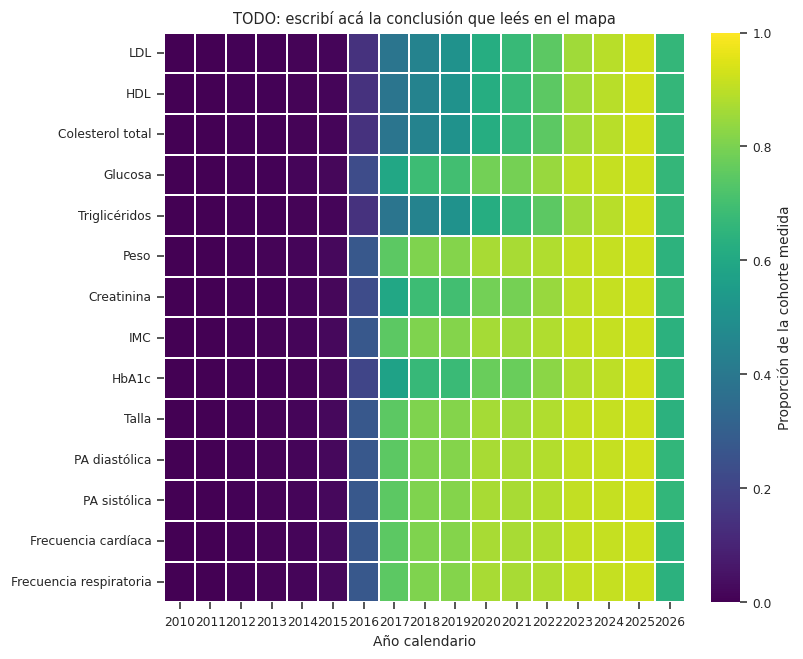

In [142]:
obs_c['anio'] = obs_c['FECHA'].dt.year
cobertura = (obs_c.pivot_table(index='analito', columns='anio',
                               values='VALUE_num', aggfunc='count', observed=True)
                  .fillna(0))
# Proporción de pacientes de la cohorte con >=1 medición de ese analito en ese año
n_coh = len(COHORTE)
cob_pac = (obs_c.groupby(['analito', 'anio'], observed=True)['PATIENT']
                .nunique().unstack(fill_value=0) / n_coh)

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 0.32 * len(cob_pac) + 1.4))
sns.heatmap(cob_pac, cmap=CMAP, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'Proporción de la cohorte medida'},
            linewidths=0.3, linecolor='white')
ax.set_xlabel('Año calendario')
ax.set_ylabel('')
ax.set_title('TODO: escribí acá la conclusión que leés en el mapa')
plt.show()


In [143]:
print((100 * cob_pac).round(0).astype(int).to_string())

anio                     2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
analito                                                                                                                      
LDL                         0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
HDL                         0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
Colesterol total            0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
Glucosa                     0     0     1     1     1     2    23    60    69    70    79    79    85    90    91    92    66
Triglicéridos               0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
Peso                        0     0     1     1     1     2    27    75    81    81    87    87    88    91    91    9

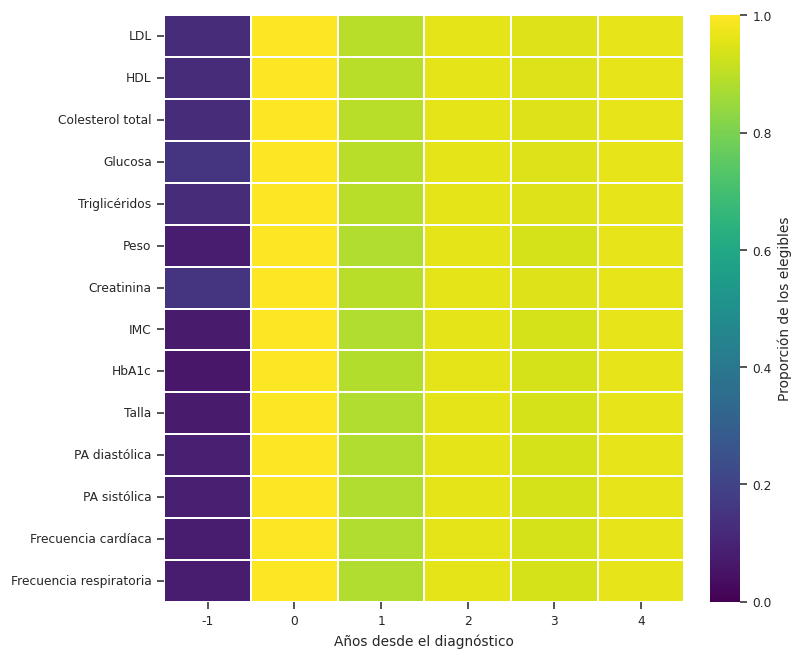

In [144]:
cob_rel = (obs_c[obs_c['dias_desde_indice'].between(-365, 365 * 5)]
           .assign(anio_rel=lambda d: (d['dias_desde_indice'] // 365))
           .groupby(['analito', 'anio_rel'], observed=True)['PATIENT']
           .nunique().unstack(fill_value=0))
# Denominador correcto: sólo quienes PUEDEN ser observados en ese año relativo
elegibles = {a: int((coh['dias_seguimiento'] >= a * 365).sum())
             for a in cob_rel.columns}
cob_rel = cob_rel.div(pd.Series(elegibles))

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 0.32 * len(cob_rel) + 1.4))
sns.heatmap(cob_rel, cmap=CMAP, vmin=0, vmax=1, ax=ax, linewidths=0.3,
            linecolor='white', cbar_kws={'label': 'Proporción de los elegibles'})
ax.set_xlabel('Años desde el diagnóstico')
ax.set_ylabel('')
plt.show()

**Lectura del mapa de disponibilidad**. El mapa superpone tres fenómenos que conviene separar antes de interpretarlo.

(a) La ventana de exportación. La proporción de la cohorte con alguna medición es exactamente cero entre 2010 y 2015 en los catorce analitos, y parcial en 2016. La transición es simultánea en todos, sin ninguna adopción progresiva: un escalón sincronizado en catorce analitos no es un fenómeno asistencial sino un artefacto del proceso de exportación. La causa está documentada en la sección 1.3b: Synthea escribe a CSV sólo los últimos diez años de historia, y con el corte de datos en agosto de 2026 el límite cae a fines de agosto de 2016. La transición parcial de 2016 corresponde a los cuatro meses de ese año que quedan dentro de la ventana.

(b) La entrada escalonada a la cohorte. El ascenso gradual desde ~0.6 en 2017 hasta ~0.9 a partir de 2021 no mide disponibilidad de datos: mide cuántos pacientes ya habían sido diagnosticados. Los 426 entran a lo largo de todo el período, y el denominador del mapa son los 426 en cada año, de modo que un paciente diagnosticado en 2023 figura como no medido en 2017 aunque sus datos de ese año existan. Interpretar esa rampa como un problema de registro sería un error; es una propiedad del diseño de la cohorte. La versión del mapa indexada por años desde el diagnóstico, con el denominador ajustado a los pacientes elegibles en cada horizonte, elimina el efecto.

(c) El truncamiento a la derecha. La caída de 2026 refleja que el dataset se corta el 27 de agosto: ese año está representado por ocho meses de doce. Cualquier serie temporal que llegue al borde debe excluirlo o normalizar por meses observados.

La pregunta con consecuencias. Si la HbA1c y el perfil lipídico muestran cobertura sistemáticamente menor que los signos vitales una vez controlados (b) y (c), eso reproduce el patrón real de un EHR —los laboratorios se solicitan con menor frecuencia que los signos vitales, que se registran en cada contacto— y la ausencia sería informativa. Si en cambio la cobertura es idéntica, se confirma que Synthea genera las catorce mediciones como un paquete atado al mismo tipo de encuentro, y la evidencia a favor de esto último es contundente: en la ventana basal, los 395 pacientes tienen los catorce analitos sin una sola cobertura parcial. Una coocurrencia perfecta de catorce estudios en 395 pacientes es imposible en datos reales. La consecuencia es que la ausencia informativa —el hecho de que tener una medición sea en sí mismo un predictor, porque quien recibe una orden es quien alguien consideró suficientemente enfermo— no puede estudiarse en este dataset, y ningún método de imputación desarrollado acá transferiría a un EHR real.


### #3 — ¿Cómo se distribuye cada variable?

Un *small multiple*: un histograma por analito, con escala propia. Es la forma correcta
de mirar 10–14 variables continuas de una vez, y es donde aparecen las bimodalidades y
los apilamientos que `describe()` no puede mostrar.


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:123: UserWarning:

The figure layout has changed to tight



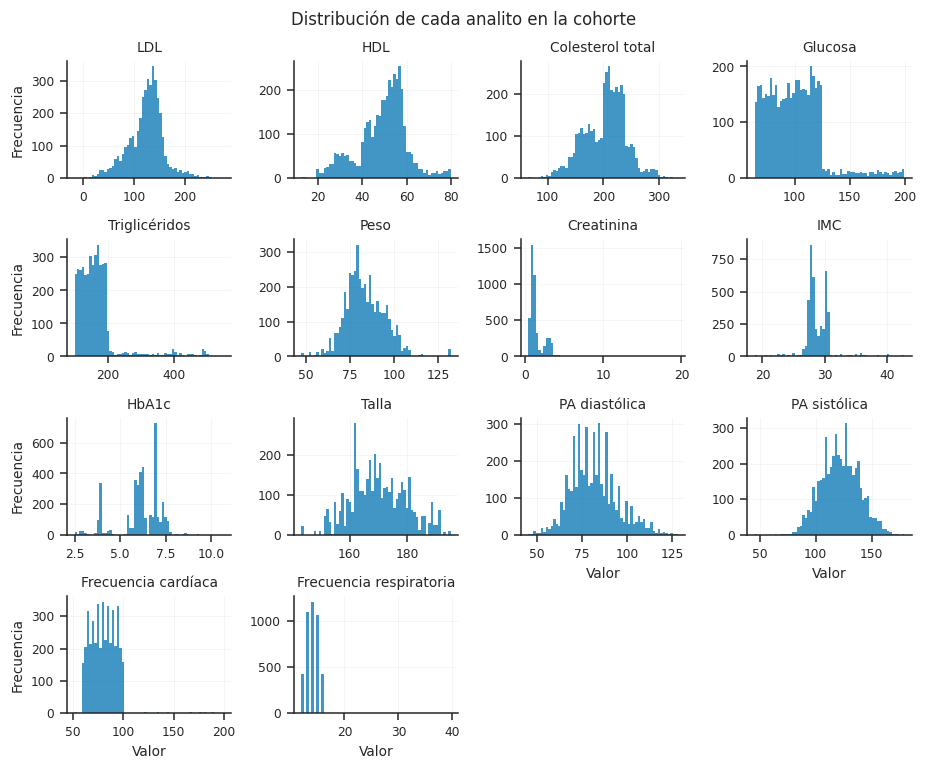

In [145]:
num = obs_c[obs_c['VALUE_num'].notna()]

g = sns.displot(
    data=num, x='VALUE_num', col='analito', col_wrap=4,
    bins=60,
    common_bins=False,        # <-- bins recalculados por panel; ESTE es el arreglo
    common_norm=False,        # irrelevante con stat='count', explícito por claridad
    height=1.7, aspect=1.25,
    facet_kws={'sharex': False, 'sharey': False},
    color=PALETA[0], edgecolor='none',
)
g.set_titles('{col_name}')
g.set_axis_labels('Valor', 'Frecuencia')
g.figure.suptitle('Distribución de cada analito en la cohorte', y=1.02)
plt.show()


In [146]:
# El contraste: el mismo contenido, resumido numéricamente
(num.groupby('analito', observed=True)['VALUE_num']
    .describe(percentiles=[.01, .25, .5, .75, .99])
    .round(2))


,count,mean,std,min,1%,25%,50%,75%,99%,max
analito,,,,,,,,,,
LDL,4028.0,123.46,34.52,-16.6,32.98,105.40,127.3,143.0,214.88,275.7
HDL,4028.0,49.31,11.03,12.6,21.90,43.30,51.2,56.3,77.27,79.9
Colesterol total,4028.0,203.68,37.62,64.8,111.06,176.70,208.1,229.1,293.12,332.9
Glucosa,4611.0,100.09,25.06,64.0,64.90,80.70,98.5,114.4,191.78,199.5
Triglicéridos,4028.0,168.10,67.93,100.0,101.10,129.00,157.2,181.6,485.00,548.6
Peso,4355.0,83.36,11.22,47.3,59.40,75.95,81.9,90.7,109.10,132.2
Creatinina,4611.0,1.49,1.07,0.4,0.60,0.90,1.1,1.5,4.50,19.5
IMC,4223.0,28.79,2.30,18.8,22.40,27.70,28.3,30.0,38.70,42.7
HbA1c,4128.0,6.13,1.13,2.5,2.90,5.90,6.2,6.9,7.70,10.7


### #4 — ¿Hay valores imposibles?

Se reutilizan los rangos de **plausibilidad** del lab02 (marco de Kahn et al. 2016, tal
como lo implementa el OHDSI Data Quality Dashboard). La distinción sigue vigente:
*implausible* ≠ *anormal*. Un IMC de 45 es anormal y real; un IMC de 900 es un error de
registro.

Se agregan dos analitos que el lab02 no tenía rango: HbA1c y glucosa.


In [147]:
# [A] rangos publicados de plausibilidad fisiológica (arXiv:2308.10781, Tabla 4)
# [C] umbrales convencionales de control de calidad (limitación declarada)
RANGOS = {
    'Frecuencia cardíaca':     (30, 200),    # [A] lpm
    'Frecuencia respiratoria': (8, 70),      # [A] rpm
    'PA sistólica':            (50, 200),    # [A] mmHg
    'PA diastólica':           (20, 150),    # [A] mmHg
    'Talla':                   (30, 250),    # [C] cm
    'Peso':                    (0.5, 500),   # [C] kg
    'IMC':                     (10, 70),     # [C] kg/m2
    'HbA1c':                   (3, 20),      # [C] %
    'Glucosa':                 (10, 1500),   # [C] mg/dL
}

filas = []
for analito, (lo, hi) in RANGOS.items():
    s = num.loc[num['analito'] == analito, 'VALUE_num']
    if s.empty:
        continue
    fuera = marcar_implausibles(s, lo, hi)
    filas.append({
        'analito': analito, 'rango': f'[{lo}, {hi}]',
        'n': int(s.notna().sum()),
        'implausibles': int(fuera.sum()),
        'pct': round(100 * fuera.mean(), 4),
        'min': round(float(s.min()), 2), 'max': round(float(s.max()), 2),
    })

sin_rango = sorted(set(num['analito'].unique()) - set(RANGOS))
print('analitos sin rango declarado (exclusión deliberada):', sin_rango)
pd.DataFrame(filas)


analitos sin rango declarado (exclusión deliberada): ['Colesterol total', 'Creatinina', 'HDL', 'LDL', 'Triglicéridos']


,analito,rango,n,implausibles,pct,min,max
0,Frecuencia cardíaca,"[30, 200]",4327,0,0.0000,51.6,200.0
1,Frecuencia respiratoria,"[8, 70]",4327,0,0.0000,12.0,39.7
2,PA sistólica,"[50, 200]",4751,1,0.0210,45.7,179.2
3,PA diastólica,"[20, 150]",4751,0,0.0000,45.0,128.0
4,Talla,"[30, 250]",4223,0,0.0000,143.2,195.1
5,Peso,"[0.5, 500]",4355,0,0.0000,47.3,132.2
6,IMC,"[10, 70]",4223,0,0.0000,18.8,42.7
7,HbA1c,"[3, 20]",4128,44,1.0659,2.5,10.7
8,Glucosa,"[10, 1500]",4611,0,0.0000,64.0,199.5


> **TODO — interpretación.** Si aparecen implausibles, decidí si son errores o casos
> clínicos extremos, como hiciste en el lab02 con las sistólicas de 40 mmHg. La política
> sigue siendo **marcar y documentar, nunca descartar en silencio**: un umbral de
> plausibilidad estrecho no limpia los datos, elimina a los pacientes más graves.

### #5 — ¿Cómo se relacionan entre sí?

Sobre los valores **basales** (último valor por paciente en la ventana
[índice − 365 d, índice + 30 d]). Correlación de **Spearman**, no de Pearson: varias de
estas variables son marcadamente asimétricas (triglicéridos, glucosa) y Pearson asume
linealidad y es sensible a la cola.


In [148]:
basal = valor_basal(obs_c, lookback=-365, lookahead=30)
basal = basal.reindex(sorted(basal.columns), axis=1)
print('pacientes con al menos un valor basal:', len(basal))
print('\ncobertura basal por analito (% de la cohorte):')
print((100 * basal.notna().sum() / len(COHORTE)).round(1).sort_values(ascending=False))


pacientes con al menos un valor basal: 395

cobertura basal por analito (% de la cohorte):
analito
Colesterol total           100.0
Creatinina                 100.0
Frecuencia cardíaca        100.0
Frecuencia respiratoria    100.0
Glucosa                    100.0
HDL                        100.0
HbA1c                      100.0
IMC                        100.0
LDL                        100.0
PA diastólica              100.0
PA sistólica               100.0
Peso                       100.0
Talla                      100.0
Triglicéridos              100.0
dtype: float64


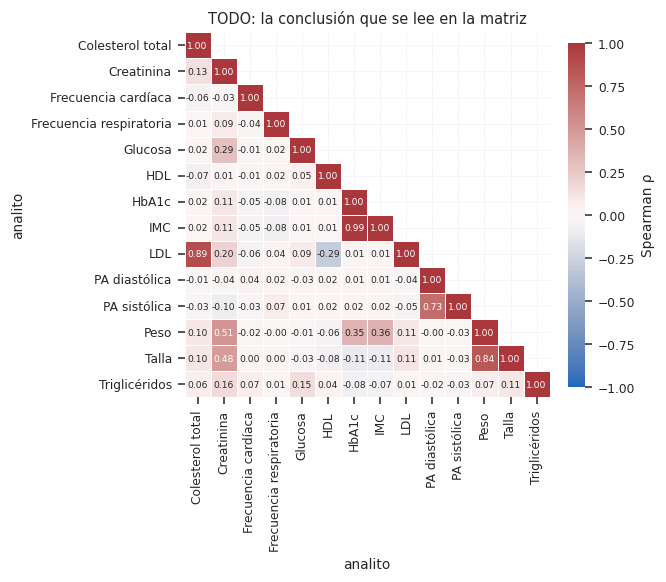

In [149]:
corr = basal.corr(method='spearman', min_periods=200)

fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.7, ANCHO_1COL * 1.6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='vlag', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            square=True, linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Spearman ρ', 'shrink': 0.7}, ax=ax)
ax.set_title('TODO: la conclusión que se lee en la matriz')
plt.show()


La paleta `vlag` es divergente y está centrada en 0 — correcto para una correlación,
donde el cero es un punto de referencia con significado. Usar `viridis` acá sería un
error: una escala secuencial sobre datos divergentes hace que −0.8 y +0.1 parezcan
igualmente "bajos".

### #6 — ¿Cambia con el tiempo?


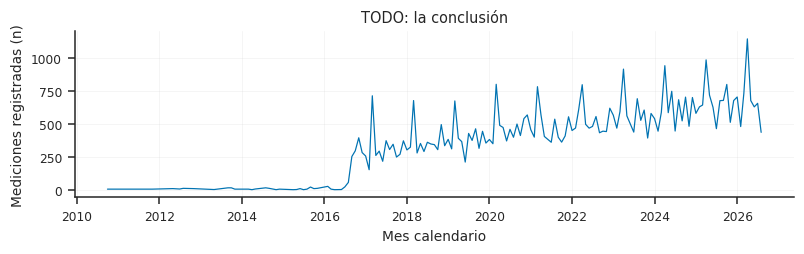

In [150]:
por_mes = (obs_c.assign(mes=obs_c['FECHA'].values.astype('datetime64[M]'))
                .groupby('mes', observed=True).size())

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 2.2))
ax.plot(por_mes.index, por_mes.values, lw=0.8, color=PALETA[0])
ax.set_xlabel('Mes calendario')
ax.set_ylabel('Mediciones registradas (n)')
ax.set_title('TODO: la conclusión')
plt.show()


### #7 — ¿Hay seguimiento suficiente?

Distribución del tiempo de observación tras la fecha índice. Es la pregunta que decide
hasta dónde puede extenderse el eje x de cualquier figura longitudinal sin que la cola
quede sostenida por un puñado de pacientes.


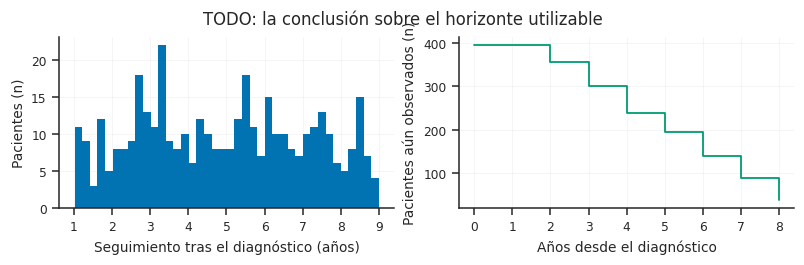

count     395.0
mean     1795.0
std       802.0
min       371.0
25%      1112.0
50%      1805.0
75%      2442.0
max      3286.0
Name: dias_seguimiento, dtype: float64


In [151]:
fig, axes = plt.subplots(1, 2, figsize=(ANCHO_2COL, 2.3))

axes[0].hist(coh['dias_seguimiento'] / 365.25, bins=40,
             color=PALETA[0], edgecolor='none')
axes[0].set_xlabel('Seguimiento tras el diagnóstico (años)')
axes[0].set_ylabel('Pacientes (n)')

# Pacientes "en riesgo" a cada horizonte: cuántos siguen observados
horiz = np.arange(0, int(coh['dias_seguimiento'].max() / 365.25) + 1)
en_riesgo = [(coh['dias_seguimiento'] >= h * 365.25).sum() for h in horiz]
axes[1].step(horiz, en_riesgo, where='post', color=PALETA[2])
axes[1].set_xlabel('Años desde el diagnóstico')
axes[1].set_ylabel('Pacientes aún observados (n)')

fig.suptitle('TODO: la conclusión sobre el horizonte utilizable')
plt.show()

print(coh['dias_seguimiento'].describe().round(0))


---
## Actividad 3 — Las tres figuras pedidas

### 3.1 Distribución de edad por sexo

Se grafican **densidades**, no conteos: los grupos tienen tamaños distintos y un
histograma de frecuencias absolutas confunde "más gente" con "más concentrada en esa
edad". El `n` de cada grupo va en la leyenda, para no esconder la base.


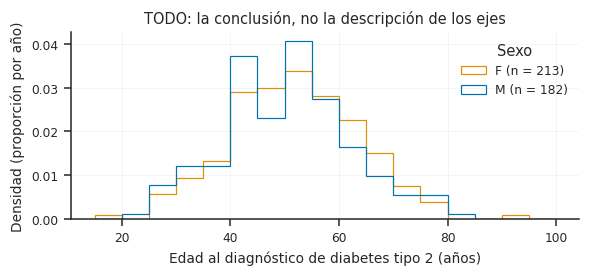

,count,mean,std,min,25%,50%,75%,max
GENDER,,,,,,,,
F,213.0,51.8,11.8,19.2,44.0,51.2,59.6,93.2
M,182.0,50.1,11.7,24.4,42.0,50.8,57.1,80.5


In [152]:
n_por_sexo = coh['GENDER'].value_counts()
etiquetas = {g: f'{g} (n = {n:,})' for g, n in n_por_sexo.items()}

fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.5, 2.4))
for sexo, d in coh.groupby('GENDER', observed=True):
    ax.hist(d['edad_indice'], bins=np.arange(15, 105, 5), density=True,
            histtype='step', lw=1.6, label=etiquetas[sexo],
            color=COLOR_SEXO.get(sexo))
ax.set_xlabel('Edad al diagnóstico de diabetes tipo 2 (años)')
ax.set_ylabel('Densidad (proporción por año)')
ax.legend(title='Sexo')
ax.set_title('TODO: la conclusión, no la descripción de los ejes')
plt.show()

coh.groupby('GENDER', observed=True)['edad_indice'].describe().round(1)


### 3.2 Evolución temporal de un analito

**HbA1c**, alineada a la fecha índice y no al calendario. Alinear por calendario
mezclaría pacientes en su primer mes de enfermedad con pacientes en su vigésimo año: la
curva resultante no describe a nadie. Alinear por tiempo desde el evento es lo que
convierte una nube de mediciones en una trayectoria.

Se recorta a [−12, +36] meses porque más allá el `n` cae y la banda de confianza se
ensancha hasta perder sentido.


In [153]:
hb = obs_c[(obs_c['analito'] == 'HbA1c') & obs_c['VALUE_num'].notna()].copy()
hb['mes'] = (hb['dias_desde_indice'] / 30.44).round()
hb = hb[hb['mes'].between(-12, 36)]
hb['bin'] = (hb['mes'] // 3) * 3          # bins trimestrales

print('mediciones:', len(hb), '| pacientes:', hb['PATIENT'].nunique())
print(hb.groupby('bin', observed=True)['PATIENT'].nunique().rename('n pacientes'))


mediciones: 1726 | pacientes: 395
bin
-12.0    225
-9.0       7
-6.0       3
-3.0       5
 0.0     395
 3.0      23
 6.0      12
 9.0      25
 12.0    333
 15.0     17
 18.0     18
 21.0     22
 24.0    325
 27.0     24
 30.0     23
 33.0     28
 36.0     22
Name: n pacientes, dtype: int64


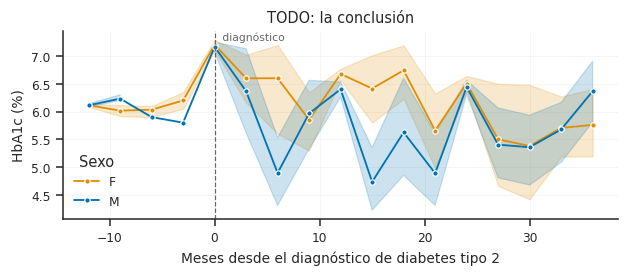

In [154]:
fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.6, 2.4))
sns.lineplot(data=hb, x='bin', y='VALUE_num', hue='GENDER',
             palette=COLOR_SEXO, errorbar=('ci', 95), n_boot=200, seed=0,
             marker='o', markersize=3.5, ax=ax)
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.text(0.4, ax.get_ylim()[1], ' diagnóstico', va='top', fontsize=7, color='0.4')
ax.set_xlabel('Meses desde el diagnóstico de diabetes tipo 2')
ax.set_ylabel('HbA1c (%)')
ax.legend(title='Sexo')
ax.set_title('TODO: la conclusión')
plt.show()


La banda es un **IC del 95 % por bootstrap** (`errorbar=('ci', 95)`), no una desviación
estándar. Se ven idénticas en el papel y significan cosas opuestas: el IC describe la
precisión de la estimación de la media y se angosta con el `n`; la DE describe la
dispersión de los pacientes y no se mueve. Declarar cuál se usó no es un detalle de
pie de figura, es la diferencia entre "sabemos bien dónde está la media" y "los
pacientes se parecen entre sí".

### 3.3 Comorbilidades más frecuentes

**Acá está el problema que mencioné al principio.** `conditions` de Synthea mezcla
*disorders* con conceptos SNOMED de situación y determinantes sociales. Mirá el
`value_counts()` crudo antes de graficar nada.


In [155]:
comorb = cond[cond['PATIENT'].isin(COHORTE) & (cond['CODE'] != CODIGO_COHORTE)].copy()
comorb = comorb.merge(coh[['PATIENT', 'fecha_indice']], on='PATIENT', how='inner')
# Antecedente: condición con inicio en o antes de la fecha índice
comorb = comorb[comorb['START'] <= comorb['fecha_indice']]

crudo = (comorb.groupby('DESCRIPTION', observed=True)['PATIENT']
               .nunique().sort_values(ascending=False).head(25))
crudo.rename('pacientes').to_frame()


,pacientes
DESCRIPTION,
Medication review due (situation),395
Full-time employment (finding),382
Stress (finding),381
Anemia (disorder),309
Prediabetes (finding),303
Gingivitis (disorder),281
Body mass index 30+ - obesity (finding),276
Part-time employment (finding),255
Received higher education (finding),245


> **TODO — clasificá esa lista.** Vas a ver conceptos como `Full-time employment`,
> `Received higher education`, `Medication review due`, `Stress`. No son comorbilidades:
> son *findings* y *situations* de SNOMED sobre determinantes sociales, que Synthea
> registra en la misma tabla. Completá `NO_CLINICAS` con lo que decidas excluir.

**Y la limitación de fondo, que va en el notebook:** "las 10 condiciones más frecuentes"
**no es** una definición de comorbilidad. Un índice de comorbilidad real (Charlson,
Elixhauser) se define sobre grupos de conceptos, no sobre códigos sueltos, y se
construye recorriendo la jerarquía del vocabulario — `concept_ancestor` en OMOP, que es
la sesión 16. Lo que se entrega acá es una descripción de frecuencias, y hay que
nombrarla así.


In [156]:
NO_CLINICAS = {
    'Full-time employment (finding)', 'Part-time employment (finding)',
    'Unemployed (finding)', 'Not in labor force (finding)',
    'Received higher education (finding)',
    'Received certificate of higher education (finding)',
    'Higher education (finding)', 'Medication review due (situation)',
    'Social isolation (finding)', 'Limited social contact (finding)',
    'Lack of access to transportation (finding)',
    'Transport problem (finding)', 'Housing unsatisfactory (finding)',
    'Reports of violence in the environment (finding)',
    'Victim of intimate partner abuse (finding)',
    'Stress (finding)', 'Has a criminal record (finding)',
    'Refugee (person)', 'Unhealthy alcohol drinking behavior (finding)',
    # Ajustá según lo que devuelva la celda anterior en TU dataset
}
# Las descripciones pueden venir sin la etiqueta semántica entre paréntesis según
# la versión de Synthea: se compara también la forma sin sufijo.
sin_sufijo = {s.split(' (')[0] for s in NO_CLINICAS}

desc = comorb['DESCRIPTION'].astype(str)
es_clinica = ~(desc.isin(NO_CLINICAS) | desc.isin(sin_sufijo))
print('registros excluidos por no ser clínicos:', (~es_clinica).sum())

top_comorb = (comorb[es_clinica].groupby('DESCRIPTION', observed=True)['PATIENT']
                    .nunique().sort_values(ascending=False).head(12))
prev = (100 * top_comorb / len(COHORTE)).rename('prevalencia_pct')
prev.round(1).to_frame()


registros excluidos por no ser clínicos: 4596


,prevalencia_pct
DESCRIPTION,
Anemia (disorder),78.2
Prediabetes (finding),76.7
Gingivitis (disorder),71.1
Body mass index 30+ - obesity (finding),69.9
Viral sinusitis (disorder),40.5
Past pregnancy history of miscarriage (situation),32.2
Chronic pain (finding),31.1
Essential hypertension (disorder),30.6
Chronic sinusitis (disorder),27.8


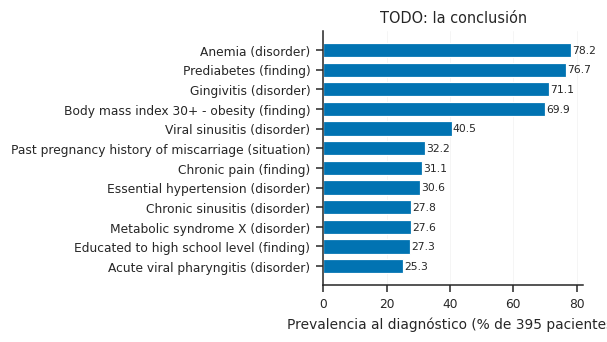

In [157]:
fig, ax = plt.subplots(figsize=(ANCHO_2COL * 0.75, 3.0))
orden = prev.sort_values()
ax.barh(orden.index.astype(str), orden.values, color=PALETA[0], height=0.72)
ax.set_xlabel(f'Prevalencia al diagnóstico (% de {len(COHORTE):,} pacientes)')
ax.set_ylabel('')
ax.grid(axis='y', visible=False)
for y, v in enumerate(orden.values):
    ax.text(v + 0.4, y, f'{v:.1f}', va='center', fontsize=7)
ax.set_title('TODO: la conclusión')
plt.show()


---
## Actividad 4 — Problemas visibles sólo al graficar

Cuatro sondas. **No todas van a mostrar algo en tu dataset** — Synthea genera valores
dentro de rango por construcción. Corré las cuatro, quedate con las dos que efectivamente
revelen algo y borrá o convertí en apéndice las otras. Reportar como hallazgo una sonda
que dio negativo es peor que no correrla.

Para cada una, el criterio de admisión es el mismo: **el estadístico correspondiente no
lo detecta**. Si `describe()` lo hubiera mostrado, no cuenta.

### Sonda A — Bimodalidad enmascarada por la media

`describe()` de la talla devuelve una media y una DE. Si la distribución tiene dos modas
(adultos y mediciones pediátricas del mismo paciente a lo largo de su vida), esa media no
corresponde a ningún paciente y la DE mide la distancia entre poblaciones, no la
variabilidad dentro de una.


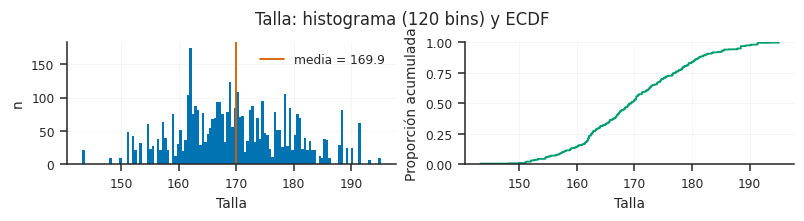

Talla → {'count': 4223.0, 'mean': 169.9, 'std': 9.72, 'min': 143.2, '25%': 162.5, '50%': 169.5, '75%': 177.0, 'max': 195.1} 



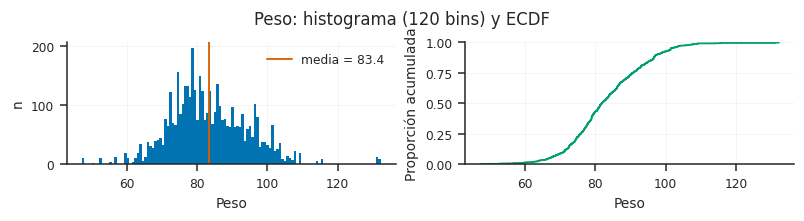

Peso → {'count': 4355.0, 'mean': 83.36, 'std': 11.22, 'min': 47.3, '25%': 75.95, '50%': 81.9, '75%': 90.7, 'max': 132.2} 



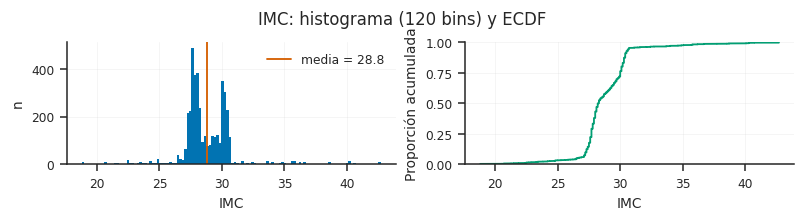

IMC → {'count': 4223.0, 'mean': 28.79, 'std': 2.3, 'min': 18.8, '25%': 27.7, '50%': 28.3, '75%': 30.0, 'max': 42.7} 



In [158]:
for analito in ['Talla', 'Peso', 'IMC']:
    s = num.loc[num['analito'] == analito, 'VALUE_num'].dropna()
    if s.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(ANCHO_2COL, 1.9))
    axes[0].hist(s, bins=120, color=PALETA[0], edgecolor='none')
    axes[0].axvline(s.mean(), color=PALETA[3], lw=1.2, label=f'media = {s.mean():.1f}')
    axes[0].set_xlabel(analito); axes[0].set_ylabel('n'); axes[0].legend()
    sns.ecdfplot(s, ax=axes[1], color=PALETA[2])
    axes[1].set_xlabel(analito); axes[1].set_ylabel('Proporción acumulada')
    fig.suptitle(f'{analito}: histograma (120 bins) y ECDF')
    plt.show()
    print(analito, '→', s.describe().round(2).to_dict(), '\n')


### Sonda B — Apilamiento de dígitos (*digit heaping*)

Con bins finos, un valor medido de verdad produce una distribución suave; un valor
*reportado* o redondeado produce picos periódicos en múltiplos de 5, 10 o 0.5. Es
invisible con 30 bins y en cualquier resumen numérico. En un EHR real es la firma de la
captura manual frente a la automática.


In [ ]:
for analito in ['PA sistólica', 'Peso', 'HbA1c']:
    s = num.loc[num['analito'] == analito, 'VALUE_num'].dropna()
    if s.empty:
        continue
    lo, hi = s.quantile([.005, .995])
    fig, ax = plt.subplots(figsize=(ANCHO_2COL, 1.7))
    ax.hist(s[(s >= lo) & (s <= hi)], bins=400, color=PALETA[0], edgecolor='none')
    ax.set_xlabel(analito)
    ax.set_ylabel('n')
    ax.set_title(f'{analito} con 400 bins — buscá picos periódicos')
    plt.show()

    # Contraste numérico: parte decimal. Si se concentra en .0 y .5, hay redondeo.
    dec = (s * 10 % 10).round().astype(int)
    print(analito, '→ último dígito decimal:',
          dec.value_counts(normalize=True).sort_index().round(3).to_dict(), '\n')


### Sonda C — Presencia informativa: cuándo se mide, no cuánto vale

Histograma de `dias_desde_indice`. Si aparece un pico en el día 0, las mediciones no se
distribuyen en el tiempo: se disparan en el encuentro diagnóstico. Consecuencia directa
para cualquier modelo posterior — *tener* una HbA1c es en sí mismo un predictor, y un
modelo entrenado sobre pacientes con HbA1c está entrenado sobre pacientes que recibieron
atención, no sobre pacientes con diabetes.

`describe()` sobre `VALUE_num` no puede ver esto: el problema no está en los valores,
está en las fechas.


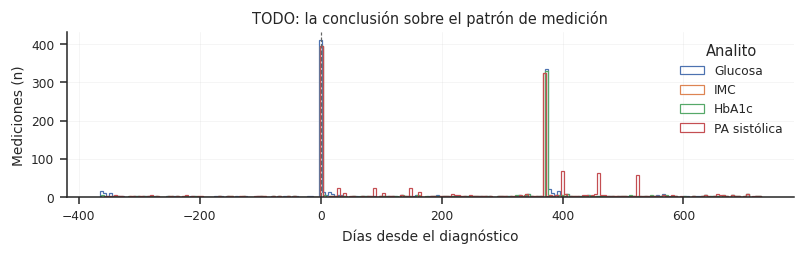

In [160]:
sub = obs_c[obs_c['dias_desde_indice'].between(-365, 730)]

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 2.2))
for i, (analito, d) in enumerate(sub.groupby('analito', observed=True)):
    if analito not in ('HbA1c', 'Glucosa', 'PA sistólica', 'IMC'):
        continue
    ax.hist(d['dias_desde_indice'], bins=220, histtype='step', lw=1.1,
            label=str(analito))
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('Días desde el diagnóstico')
ax.set_ylabel('Mediciones (n)')
ax.legend(title='Analito')
ax.set_title('TODO: la conclusión sobre el patrón de medición')
plt.show()


### Sonda D — Estructura bivariada: sistólica vs. diastólica

Las dos marginales pueden ser impecables y la relación entre ambas ser imposible. Se
grafica la nube con densidad (hexbin, `viridis`) y se marca la diagonal
sistólica = diastólica: cualquier punto por debajo es físicamente imposible.


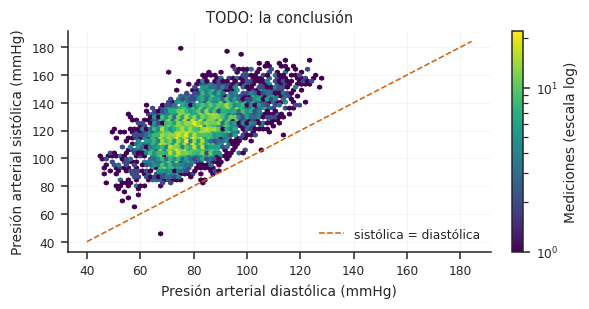

presión de pulso — mín: -22.0 | pares con sistólica <= diastólica: 2


In [161]:
pa = (obs_c[obs_c['analito'].isin(['PA sistólica', 'PA diastólica'])]
      .pivot_table(index=['PATIENT', 'FECHA'], columns='analito',
                   values='VALUE_num', aggfunc='max', observed=True)
      .dropna())

fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.5, 2.7))
hb2 = ax.hexbin(pa['PA diastólica'], pa['PA sistólica'],
                gridsize=55, cmap=CMAP, bins='log', mincnt=1)
lim = [pa.min().min() - 5, pa.max().max() + 5]
ax.plot(lim, lim, color=PALETA[3], lw=1, ls='--', label='sistólica = diastólica')
ax.set_xlabel('Presión arterial diastólica (mmHg)')
ax.set_ylabel('Presión arterial sistólica (mmHg)')
ax.legend(loc='lower right')
fig.colorbar(hb2, ax=ax, label='Mediciones (escala log)')
ax.set_title('TODO: la conclusión')
plt.show()

pp = pa['PA sistólica'] - pa['PA diastólica']
print('presión de pulso — mín:', round(pp.min(), 1),
      '| pares con sistólica <= diastólica:', int((pp <= 0).sum()))


> **TODO — elegí dos y redactalos.** Para cada uno: (1) qué se ve en la figura, (2) por
> qué `describe()` no lo muestra, (3) qué consecuencia tiene para un análisis posterior.
> El punto (2) es el que el enunciado evalúa; si no podés escribirlo, el hallazgo no
> califica.


---
## Actividad 5 — Figura multipanel 2×2

Cuatro paneles que cubren cuatro tipos de pregunta distintos: distribución univariada,
trayectoria temporal, ranking categórico y densidad bivariada. Repetir cuatro veces el
mismo tipo de gráfica desperdicia el formato multipanel.

Decisiones de composición:

- **`figsize=(7.2, 5.4)`** — ancho de dos columnas de revista, en pulgadas.
- **Etiquetas A–D** en la esquina superior izquierda de cada panel, en negrita: es la
  convención para poder referirse a ellos desde el texto ("como muestra la Fig. 1C").
- **Dependencia de celdas:** el panel D reutiliza `pa` y `lim`, definidos en la Sonda D
  de la Actividad 4. Si borrás esa celda, movéle el cálculo acá.
- **`ax.set_rasterized(True)` en el panel del hexbin** — un hexbin con miles de celdas
  produce un PDF enorme si se guarda vectorial. Rasterizar *ese Axes* mantiene el texto
  y los ejes como vectores y convierte solo la nube en píxeles. Es el compromiso estándar
  para figuras densas.


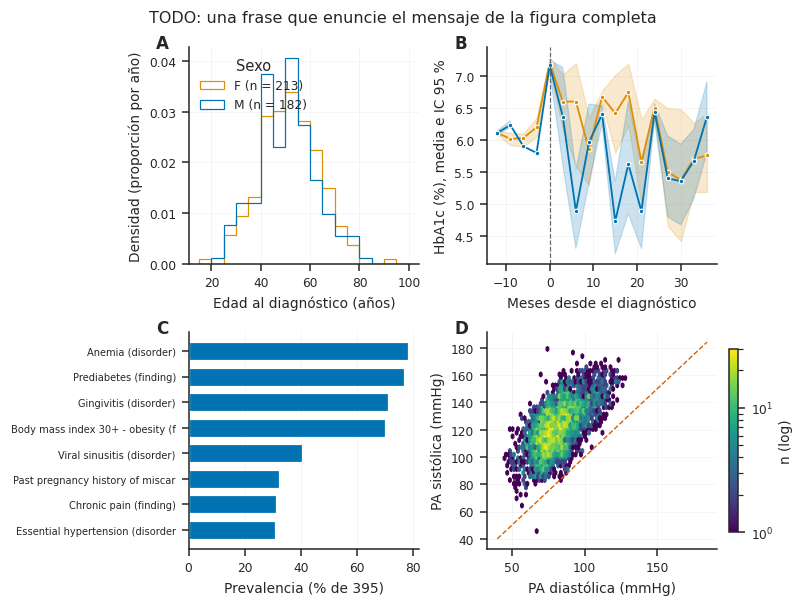

In [162]:
fig, axes = plt.subplots(2, 2, figsize=(ANCHO_2COL, 5.4))
axA, axB, axC, axD = axes.ravel()

# --- A: edad al diagnóstico por sexo ---
for sexo, d in coh.groupby('GENDER', observed=True):
    axA.hist(d['edad_indice'], bins=np.arange(15, 105, 5), density=True,
             histtype='step', lw=1.5, color=COLOR_SEXO.get(sexo),
             label=f'{sexo} (n = {len(d):,})')
axA.set_xlabel('Edad al diagnóstico (años)')
axA.set_ylabel('Densidad (proporción por año)')
axA.legend(title='Sexo', loc='upper left')

# --- B: HbA1c relativa al diagnóstico ---
sns.lineplot(data=hb, x='bin', y='VALUE_num', hue='GENDER', palette=COLOR_SEXO,
             errorbar=('ci', 95), n_boot=200, seed=0, marker='o', markersize=3,
             legend=False, ax=axB)
axB.axvline(0, color='0.4', ls='--', lw=0.8)
axB.set_xlabel('Meses desde el diagnóstico')
axB.set_ylabel('HbA1c (%), media e IC 95 %')

# --- C: comorbilidades ---
orden = prev.sort_values().tail(8)
axC.barh([str(i)[:32] for i in orden.index], orden.values,
         color=PALETA[0], height=0.7)
axC.set_xlabel(f'Prevalencia (% de {len(COHORTE):,})')
axC.grid(axis='y', visible=False)
axC.tick_params(axis='y', labelsize=6.5)

# --- D: sistólica vs diastólica ---
h = axD.hexbin(pa['PA diastólica'], pa['PA sistólica'], gridsize=45,
               cmap=CMAP, bins='log', mincnt=1, rasterized=True)
axD.plot(lim, lim, color=PALETA[3], lw=0.9, ls='--')
axD.set_xlabel('PA diastólica (mmHg)')
axD.set_ylabel('PA sistólica (mmHg)')
fig.colorbar(h, ax=axD, label='n (log)', shrink=0.85)
axD.set_rasterized(True)

for letra, ax in zip('ABCD', (axA, axB, axC, axD)):
    ax.text(-0.14, 1.06, letra, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

fig.suptitle('TODO: una frase que enuncie el mensaje de la figura completa',
             fontsize=10.5)
plt.show()


---
## Actividad 6 — La misma figura en matplotlib, seaborn y plotly

Se replica el **panel B** (HbA1c media con IC 95 % por sexo). Se elige ésa
deliberadamente: es una figura con una **capa estadística**, y ahí es donde las tres
herramientas dejan de ser equivalentes. Si se comparara un simple diagrama de barras, las
tres se verían igual de bien y la comparación no enseñaría nada.

### 6.1 matplotlib puro


In [ ]:
def ic95_bootstrap(x, n_boot=200, rng=None):
    # IC 95 % de la media por bootstrap percentil.
    rng = np.random.default_rng(0) if rng is None else rng
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return np.nan, np.nan
    medias = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return np.percentile(medias, [2.5, 97.5])


fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.6, 2.4))
for sexo, d in hb.groupby('GENDER', observed=True):
    resumen_sexo = []
    for b, x in d.groupby('bin', observed=True)['VALUE_num']:
        lo, hi = ic95_bootstrap(x)
        resumen_sexo.append({'bin': b, 'media': x.mean(), 'lo': lo, 'hi': hi})
    r = pd.DataFrame(resumen_sexo).sort_values('bin')
    ax.plot(r['bin'], r['media'], marker='o', markersize=3,
            color=COLOR_SEXO.get(sexo), label=str(sexo))
    ax.fill_between(r['bin'], r['lo'], r['hi'],
                    color=COLOR_SEXO.get(sexo), alpha=0.2, linewidth=0)
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('Meses desde el diagnóstico')
ax.set_ylabel('HbA1c (%)')
ax.legend(title='Sexo')
ax.set_title('matplotlib puro')
plt.show()


### 6.2 seaborn


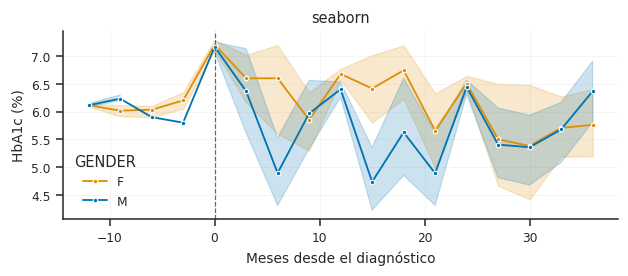

In [164]:
fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.6, 2.4))
sns.lineplot(data=hb, x='bin', y='VALUE_num', hue='GENDER', palette=COLOR_SEXO,
             errorbar=('ci', 95), n_boot=200, seed=0, marker='o', markersize=3, ax=ax)
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('Meses desde el diagnóstico')
ax.set_ylabel('HbA1c (%)')
ax.set_title('seaborn')
plt.show()


### 6.3 plotly

plotly **no tiene** una capa de agregación estadística equivalente: `px.line` dibuja lo
que se le da. El intervalo hay que calcularlo aparte —reutilizando la función del
apartado 6.1— y dibujarlo como dos trazas con relleno. Eso es en sí mismo el resultado de
la comparación.


In [165]:
import plotly.graph_objects as go

resumen = []
for sexo, d in hb.groupby('GENDER', observed=True):
    for b, x in d.groupby('bin', observed=True)['VALUE_num']:
        lo, hi = ic95_bootstrap(x)
        resumen.append({'GENDER': sexo, 'bin': b, 'media': np.mean(x),
                        'lo': lo, 'hi': hi, 'n': len(x)})
resumen = pd.DataFrame(resumen).sort_values(['GENDER', 'bin'])

fig = go.Figure()
for sexo, d in resumen.groupby('GENDER'):
    c = mpl.colors.to_hex(COLOR_SEXO.get(sexo, PALETA[0]))
    fig.add_trace(go.Scatter(
        x=list(d['bin']) + list(d['bin'][::-1]),
        y=list(d['hi']) + list(d['lo'][::-1]),
        fill='toself', fillcolor=c, opacity=0.18,
        line={'width': 0}, hoverinfo='skip', showlegend=False))
    fig.add_trace(go.Scatter(
        x=d['bin'], y=d['media'], name=str(sexo), mode='lines+markers',
        line={'color': c, 'width': 2},
        customdata=d[['n']],
        hovertemplate='Mes %{x}<br>HbA1c %{y:.2f} %<br>n = %{customdata[0]}<extra></extra>'))

fig.update_layout(
    template='simple_white', width=560, height=340,
    xaxis_title='Meses desde el diagnóstico', yaxis_title='HbA1c (%)',
    legend_title='Sexo', margin={'l': 60, 'r': 20, 't': 40, 'b': 50})
fig.add_vline(x=0, line_dash='dash', line_color='gray', line_width=1)
fig.show()


### 6.4 Comparación

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Líneas para esta figura | ~18 | ~6 | ~22 (+ la función de IC) |
| Quién calcula el IC | vos | la librería | vos |
| Control fino | total | el que hereda de matplotlib | limitado y con otra API |
| Facetado | a mano con `subplots` | `col=` / `row=` | `facet_col=` en `express` |
| Exportable a PDF vectorial | sí, nativo | sí (devuelve objetos matplotlib) | requiere `kaleido`, y el resultado es peor |
| Aporta | reproducibilidad exacta y control | velocidad de iteración | *hover* con el `n` y zoom |

> **TODO — tu conclusión.** La pregunta del enunciado no es cuál es "mejor". Es dónde
> conviene cada una en tu flujo. Mi lectura, que podés discutir: seaborn para explorar
> (menos decisiones que tomar = menos oportunidades de equivocarte), matplotlib para la
> figura final (control total sobre lo que se publica), plotly para inspeccionar atípicos
> —el hover con el identificador del paciente es algo que las otras dos no dan— y nunca
> como entregable en PDF.

**Un matiz que conviene notar en 6.1 vs 6.2:** las bandas de matplotlib y de seaborn no
son idénticas aunque ambas sean IC 95 % por bootstrap, porque el remuestreo usa semillas
y implementaciones distintas. Si la conclusión de tu figura cambia según cuál de las dos
usaste, la conclusión no está sostenida por los datos.


---
## Actividad 7 — Tabla 1

La tabla de características basales. Cuatro decisiones que la hacen defendible:

1. **Estratificación por sexo.** Es una descripción, no una comparación de tratamiento.
2. **Variables asimétricas en mediana [IQR]**, no en media ± DE. Días de seguimiento,
   triglicéridos y glucosa tienen colas largas; reportar una media ahí describe mal a la
   población. Se declaran en `nonnormal`.
3. **SMD en lugar de valor p.** Es la convención en investigación con datos del mundo
   real (Austin 2009, y es lo que reporta OHDSI). Motivo: el valor p depende del tamaño
   muestral, de modo que con `n` grande cualquier diferencia trivial resulta
   "significativa" y con `n` chico una diferencia clínicamente relevante no lo es. La SMD
   mide **magnitud** y es independiente del `n`; el umbral convencional es 0.1.
4. **`missing=True`.** La tabla reporta cuántos valores faltan en cada variable. Una
   Tabla 1 que no declara sus faltantes esconde a quién describe realmente.


In [166]:
tab = coh[['PATIENT', 'GENDER', 'RACE', 'ETHNICITY', 'edad_indice',
           'dias_seguimiento', 'fallecido']].copy()
tab = tab.merge(basal, left_on='PATIENT', right_index=True, how='left')

# Número de encuentros previos al índice: proxy de contacto con el sistema de salud
enc2 = enc[['PATIENT', 'START']].copy()
enc2['PATIENT'] = enc2['PATIENT'].astype(str)
enc2['START'] = a_dia_naive(enc2['START'])
enc2 = enc2[enc2['PATIENT'].isin(COHORTE)].merge(
    coh[['PATIENT', 'fecha_indice']], on='PATIENT', how='inner')
n_enc = (enc2[enc2['START'] <= enc2['fecha_indice']]
         .groupby('PATIENT').size().rename('n_encuentros_previos'))
tab = tab.merge(n_enc, left_on='PATIENT', right_index=True, how='left')
tab['n_encuentros_previos'] = tab['n_encuentros_previos'].fillna(0)

# Número de comorbilidades clínicas previas
n_com = (comorb[es_clinica].groupby('PATIENT')['CODE']
         .nunique().rename('n_comorbilidades'))
tab = tab.merge(n_com, left_on='PATIENT', right_index=True, how='left')
tab['n_comorbilidades'] = tab['n_comorbilidades'].fillna(0)

tab = tab.drop(columns='PATIENT')
print(tab.shape)
tab.head()


(395, 22)


,GENDER,RACE,ETHNICITY,edad_indice,dias_seguimiento,fallecido,Colesterol total,Creatinina,Frecuencia cardíaca,Frecuencia respiratoria,...,HbA1c,IMC,LDL,PA diastólica,PA sistólica,Peso,Talla,Triglicéridos,n_encuentros_previos,n_comorbilidades
0,M,white,nonhispanic,37.218344,1102,False,191.600006,1.3,95.0,15.0,...,7.3,29.200001,112.300003,114.0,151.0,91.400002,177.000000,147.800003,10,14
1,M,asian,nonhispanic,42.028747,3258,False,199.899994,1.1,82.0,16.0,...,6.9,27.299999,121.500000,102.0,122.0,77.900002,168.800003,123.599998,5,6
2,F,white,nonhispanic,54.064339,1007,True,166.600006,1.0,76.0,14.0,...,7.6,30.299999,87.199997,48.0,95.0,79.300003,161.899994,145.699997,41,13
3,F,white,nonhispanic,56.191650,1918,False,197.199997,1.2,84.0,14.0,...,6.8,27.100000,142.000000,71.0,101.0,86.199997,178.300003,142.000000,18,11
4,M,white,nonhispanic,40.016427,2047,False,203.000000,1.9,91.0,13.0,...,7.3,29.100000,127.400002,100.0,130.0,96.300003,181.899994,135.300003,8,7


In [ ]:
from tableone import TableOne

continuas = [c for c in tab.columns
             if pd.api.types.is_numeric_dtype(tab[c]) and tab[c].nunique() > 8]
categoricas = ['RACE', 'ETHNICITY', 'fallecido']

# Asimétricas → mediana [IQR]. Se elige por la asimetría observada, no por defecto.
asimetria = tab[continuas].skew().abs().sort_values(ascending=False)
print('asimetría absoluta por variable:')
print(asimetria.round(2))
no_normales = asimetria[asimetria > 1].index.tolist()
print('\nse reportan como mediana [IQR]:', no_normales)


In [168]:
ETIQUETAS = {
    'edad_indice': 'Edad al diagnóstico, años',
    'dias_seguimiento': 'Seguimiento tras el diagnóstico, días',
    'n_encuentros_previos': 'Encuentros previos al diagnóstico, n',
    'n_comorbilidades': 'Comorbilidades previas, n',
    'fallecido': 'Fallecido durante el seguimiento',
    'RACE': 'Raza', 'ETHNICITY': 'Etnia',
}

tabla1 = TableOne(
    tab,
    columns=continuas + categoricas,
    categorical=categoricas,
    nonnormal=no_normales,
    groupby='GENDER',
    rename=ETIQUETAS,
    smd=True,        # magnitud de la diferencia, independiente del n
    pval=False,      # ver justificación arriba
    missing=True,
    decimals=1,
)
tabla1


/usr/local/lib/python3.13/dist-packages/tableone/preprocessors.py:87: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.13/dist-packages/tableone/tables.py:399: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/usr/local/lib/python3.13/dist-packages/tableone/tables.py:399: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/usr/local/lib/python3.13/dist-packages/tableone/tables.py:399: FutureWarning:

The default value of observed=False is deprecated and will chang

InvalidIndexError: slice(None, None, None)

In [ ]:
TAB1 = BASE03 / 'tabla1_cohorte_t2d'
tabla1.to_csv(f'{TAB1}.csv')
tabla1.to_html(f'{TAB1}.html')
try:
    tabla1.to_latex(f'{TAB1}.tex')
except Exception as e:            # noqa: BLE001
    print('LaTeX no exportado:', e)
print('Tabla 1 exportada a', BASE03)


> **TODO — comentá la Tabla 1.** Buscá SMD > 0.1 y decidí si la diferencia es
> clínicamente relevante o un artefacto del generador. Y mirá la columna `Missing`: si
> algún laboratorio basal falta en más del 50 % de la cohorte, no pertenece a una Tabla 1
> — pertenece a una nota sobre disponibilidad de datos.


---
## Actividad 8 — Exportación

PDF vectorial (texto seleccionable y editable, tipografía embebida como TrueType) y PNG
a 300 dpi. Se reconstruye la figura dentro de una función: una figura que solo existe
como efecto secundario de una celda no es reproducible, y si el kernel se reinicia
desaparece.


In [ ]:
def figura_principal():
    # Construye y devuelve la figura 2x2 del entregable.
    fig, axes = plt.subplots(2, 2, figsize=(ANCHO_2COL, 5.4))
    axA, axB, axC, axD = axes.ravel()

    for sexo, d in coh.groupby('GENDER', observed=True):
        axA.hist(d['edad_indice'], bins=np.arange(15, 105, 5), density=True,
                 histtype='step', lw=1.5, color=COLOR_SEXO.get(sexo),
                 label=f'{sexo} (n = {len(d):,})')
    axA.set_xlabel('Edad al diagnóstico (años)')
    axA.set_ylabel('Densidad (proporción por año)')
    axA.legend(title='Sexo', loc='upper left')

    sns.lineplot(data=hb, x='bin', y='VALUE_num', hue='GENDER', palette=COLOR_SEXO,
                 errorbar=('ci', 95), n_boot=200, seed=0, marker='o', markersize=3,
                 legend=False, ax=axB)
    axB.axvline(0, color='0.4', ls='--', lw=0.8)
    axB.set_xlabel('Meses desde el diagnóstico')
    axB.set_ylabel('HbA1c (%), media e IC 95 %')

    o = prev.sort_values().tail(8)
    axC.barh([str(i)[:32] for i in o.index], o.values, color=PALETA[0], height=0.7)
    axC.set_xlabel(f'Prevalencia (% de {len(COHORTE):,})')
    axC.grid(axis='y', visible=False)
    axC.tick_params(axis='y', labelsize=6.5)

    h = axD.hexbin(pa['PA diastólica'], pa['PA sistólica'], gridsize=45,
                   cmap=CMAP, bins='log', mincnt=1, rasterized=True)
    axD.plot(lim, lim, color=PALETA[3], lw=0.9, ls='--')
    axD.set_xlabel('PA diastólica (mmHg)')
    axD.set_ylabel('PA sistólica (mmHg)')
    fig.colorbar(h, ax=axD, label='n (log)', shrink=0.85)
    axD.set_rasterized(True)

    for letra, ax in zip('ABCD', (axA, axB, axC, axD)):
        ax.text(-0.14, 1.06, letra, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

    fig.suptitle('TODO: el mensaje de la figura', fontsize=10.5)
    return fig


fig = figura_principal()
fig.savefig(FIG / 'figura_principal.pdf')                 # vectorial, fuentes TrueType
fig.savefig(FIG / 'figura_principal.png', dpi=300)        # 300 dpi
plt.close(fig)

for f in sorted(FIG.iterdir()):
    print(f.name, '—', round(f.stat().st_size / 1024, 1), 'KB')


In [ ]:
# Verificación de que el PDF salió vectorial y con las fuentes embebidas correctamente
!pdffonts "{FIG}/figura_principal.pdf" 2>/dev/null || echo 'pdffonts no disponible'

from PIL import Image
im = Image.open(FIG / 'figura_principal.png')
print('PNG:', im.size, 'px |', im.info.get('dpi'), 'dpi')
print('esperado:', round(ANCHO_2COL * 300), 'px de ancho aprox. (más el bbox tight)')


En la salida de `pdffonts`, la columna `type` debe decir **TrueType** (o `Type 42`), no
`Type 3`. Type 3 es el default de matplotlib, no es editable en Illustrator y varias
revistas lo rechazan automáticamente en el envío. Lo evitamos con
`rcParams['pdf.fonttype'] = 42` en la sección 0.5.

Se exportan también las figuras individuales de las actividades 3 y 4, por si el revisor
las pide sueltas.


In [ ]:
def exportar(fig, nombre):
    fig.savefig(FIG / f'{nombre}.pdf')
    fig.savefig(FIG / f'{nombre}.png', dpi=300)
    print('exportado:', nombre)

# Ejemplo: reconstruí y exportá las que quieras conservar sueltas.
# fig, ax = plt.subplots(...); ...; exportar(fig, 'fig02_hba1c_por_sexo')


---
## Extra (opcional) — Kaplan–Meier desde el diagnóstico

No lo pide el enunciado, pero es la figura clínica canónica de una cohorte con fecha
índice y es la que la sesión marca como obligatoria con **tabla de pacientes en riesgo**.
Sin esa tabla, la cola derecha de la curva puede estar sostenida por tres pacientes y no
hay forma de saberlo mirando.

Suma valor al portafolio y es transferible casi tal cual al proyecto final.


In [ ]:
HACER_KM = True

if HACER_KM:
    from lifelines import KaplanMeierFitter
    from lifelines.plotting import add_at_risk_counts

    coh['anios_seguimiento'] = coh['dias_seguimiento'] / 365.25
    fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.7, 3.4))
    ajustes = []
    for sexo, d in coh.groupby('GENDER', observed=True):
        km = KaplanMeierFitter(label=str(sexo))
        km.fit(d['anios_seguimiento'], event_observed=d['fallecido'])
        km.plot_survival_function(ax=ax, ci_show=True, color=COLOR_SEXO.get(sexo))
        ajustes.append(km)
    ax.set_xlabel('Años desde el diagnóstico de diabetes tipo 2')
    ax.set_ylabel('Supervivencia estimada')
    ax.set_ylim(0, 1.02)
    ax.set_title('TODO: la conclusión')
    add_at_risk_counts(*ajustes, ax=ax)
    plt.show()


> **Advertencia obligatoria si incluís esta figura.** La cohorte exige 365 días de
> seguimiento, así que **por construcción nadie puede morir antes del año**: la curva es
> plana en el primer año por un artefacto del diseño, no por biología. Es sesgo de
> supervivencia inducido por el criterio de inclusión. Si querés una curva interpretable,
> hay que sacar ese criterio o arrancar el eje en t = 1 año. Dejar la figura sin esa
> aclaración sería un error grave, y es exactamente el tipo de cosa que un revisor
> pregunta.


---
## Cierre — Tres hallazgos en lenguaje clínico

El criterio de evaluación pide tres hallazgos redactados para que los lea un colega
clínico. La prueba: **ningún nombre de función, de columna ni de librería puede aparecer
en el texto.** "El `groupby` mostró que" no es lenguaje clínico. "Los pacientes
diagnosticados después de los 65 años presentaron" sí lo es.

Los tres deben tener número, y cada número debe salir de una celda de este notebook.

---

**Hallazgo 1 — Sobre la cohorte.**
> *TODO.* Tamaño, edad al diagnóstico, distribución por sexo, seguimiento mediano. Una
> frase que un clínico pueda repetir en un ateneo.

**Hallazgo 2 — Sobre la trayectoria del analito.**
> *TODO.* Qué le pasa a la HbA1c alrededor del diagnóstico. Si sube antes y baja después,
> eso es el efecto del tratamiento haciéndose visible; si no se mueve, eso también es un
> hallazgo y hay que decirlo.

**Hallazgo 3 — Sobre la calidad de los datos.**
> *TODO.* Uno de los dos problemas de la Actividad 4, redactado con su consecuencia: qué
> análisis quedaría mal hecho si alguien usara estos datos sin saberlo.

---

### Limitaciones declaradas

1. **Datos sintéticos.** Synthea genera valores dentro de rango fisiológico por
   construcción. El entregable de la Actividad 4 es el **procedimiento de detección**, no
   la tasa de error encontrada. Sobre un EHR real las mismas sondas detectarían errores de
   unidad (peso en libras cargado como kilogramos), errores de tipeo y valores centinela.
2. **Comorbilidades por frecuencia, no por índice validado.** No es Charlson ni
   Elixhauser; es un conteo de códigos sueltos con exclusión manual de conceptos sociales.
   La versión correcta requiere recorrer la jerarquía del vocabulario (`concept_ancestor`,
   sesión 16).
3. **Sesgo de supervivencia** por el criterio de ≥ 365 días de seguimiento.
4. **Presencia informativa**: los analitos se miden cuando alguien los pide, y quién
   recibe una orden depende de la gravedad. Todo análisis restringido a quienes tienen el
   valor es un análisis de una subpoblación seleccionada.
5. **Rangos de plausibilidad de origen mixto**: los antropométricos son convencionales y
   no citables, como ya se declaró en el lab02.

### Hacia dónde sigue esto

Lo que se hizo a mano acá tiene un nombre y una herramienta en el resto del curso:

| En este lab | Se formaliza en |
|---|---|
| Fecha índice y criterios de inclusión | Diseño de cohortes en OMOP con SQL (sesión 17) |
| Tabla de atrición | Feasibility y attrition tables en OHDSI (sesión 18) |
| Filtrar por código y no por texto | Vocabularios estándar: SNOMED, LOINC (sesiones 14–15) |
| Comorbilidades por jerarquía | `concept_relationship` y `concept_ancestor` (sesión 16) |
| Rangos de plausibilidad | Data Quality Dashboard de OHDSI |
| Valores basales en ventana | Feature engineering clínico (sesión 23) |

---

### Entrega

```
s03-visualizacion-eda/
└── tu-entrega/
    ├── eda_cohorte.ipynb
    ├── eda_utils.py
    ├── test_eda_utils.py
    ├── tabla1_cohorte_t2d.csv / .html
    └── figuras/
        ├── figura_principal.pdf
        └── figura_principal.png
```

Pull request contra `main` con título `lab03: EDA de cohorte de diabetes tipo 2 en
Synthea`.
